# FAST NUCES - Computer Vision (CS4063)
# Lab 06: Edges, Lines, Circles, Keypoints, Wavelets
**Instructor:** Talha Shahid  
**Topic:** Structural Feature Extraction, Geometric Transforms, SIFT, and Wavelet Multiresolution Analysis  

---

## Lab Objectives & Rules
- Implement **8 complete computer vision scenarios**:
  1. Computer Screen Detection (Hough Lines)
  2. Asset Tracking in a Computer Lab (SIFT)
  3. Anomaly Detection in Sensor Data (Wavelet Analysis)
  4. Object Recognition in Video (SIFT + Homography)
  5. Panoramic Image Stitching (SIFT + Perspective Warping)
  6. Autonomous Vehicle Lane Detection (Hough Lines)
  7. Coins Detection and Automated Counting (Hough Circles)
  8. Smart Security System (Zone Boundary Detection + Baseline Calibration)
  + **Foundation Section**: Sobel, Canny, and Laplacian of Gaussian (LoG)
- For every task:
  - Display the original input and resulting output.
  - State every parameter chosen and a concrete line of why.
  - Save output figures to disk (`plt.savefig` or `cv2.imwrite`).


## 0. Setup and Environment Initialization
Ensure all required libraries are loaded: OpenCV, NumPy, Matplotlib, PyWavelets (`pywt`), and Pandas.


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pywt
import pandas as pd
import os

# Ensure assets directory exists and generate test images if needed
import generate_all_assets
generate_all_assets.make_edges_input()
generate_all_assets.make_lab_screens()
generate_all_assets.make_asset_tracking_data()
generate_all_assets.make_video_object_data()
generate_all_assets.make_panorama_data()
generate_all_assets.make_road_data()
generate_all_assets.make_security_video()

print(f"OpenCV Version: {cv2.__version__}")
print(f"PyWavelets Version: {pywt.__version__}")


Created assets/edges_input.jpg
Created assets/lab_screens.jpg
Created assets for Task 2 (Asset tracking catalogue and scene)


Created assets/object.jpg and assets/test_video.mp4
Created assets/pan1.jpg, pan2.jpg, pan3.jpg
Created assets/road.jpg


Created assets/security_video.mp4
OpenCV Version: 4.13.0
PyWavelets Version: 1.8.0


---
## Foundation: Boundary Detection (Sobel, Canny, LoG)

### Theory & Mathematical Intuition:
1. **Sobel First Derivatives**:
   - $G_x = \begin{bmatrix} -1 & 0 & 1 \\ -2 & 0 & 2 \\ -1 & 0 & 1 \end{bmatrix} * I$, $G_y = \begin{bmatrix} -1 & -2 & -1 \\ 0 & 0 & 0 \\ 1 & 2 & 1 \end{bmatrix} * I$
   - Uses `cv2.CV_64F` because derivatives take negative values on bright-to-dark edges.
   - Magnitude: $G = \sqrt{G_x^2 + G_y^2}$.
2. **Canny Edge Detector**:
   - Gaussian smoothing $\to$ Gradient computation $\to$ Non-maximum suppression (NMS) $\to$ Hysteresis thresholding ($50, 150$).
3. **Laplacian of Gaussian (LoG)**:
   - Second derivative $\nabla^2 I = \frac{\partial^2 I}{\partial x^2} + \frac{\partial^2 I}{\partial y^2}$. Edges lie at zero-crossings.


Task 0 completed successfully. Saved output to task0_edges_output.png


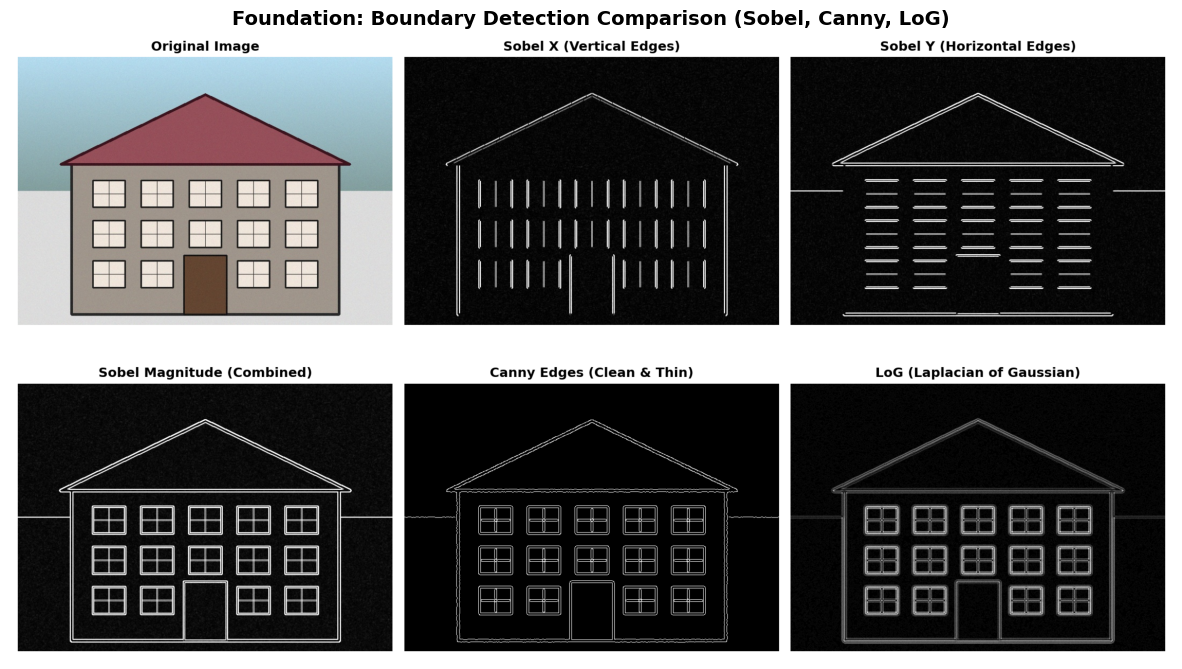

In [2]:
# Foundation: Sobel, Canny, LoG
import task0_edges
task0_edges.run_task0("assets/edges_input.jpg", "task0_edges_output.png")

# Display inline
res_img = cv2.imread("task0_edges_output.png")
plt.figure(figsize=(15, 9))
plt.imshow(cv2.cvtColor(res_img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Foundation: Boundary Detection Comparison (Sobel, Canny, LoG)", fontsize=14, fontweight="bold")
plt.show()


---
## Task 1: Computer Screen Detection in a Computer Lab
**Technique:** Hough Line Transformation (`HoughLinesP`), Morphological Closing, Contour Analysis, and Luminance Profiling.

### Parameters Chosen & Justification:
- `Canny(50, 150)`: 1:3 ratio isolates outer bezel borders while suppressing interior display reflections.
- `HoughLinesP(threshold=25, minLineLength=25, maxLineGap=25)`:
  - `threshold=25`: Minimum votes to qualify line segment.
  - `minLineLength=25`: Ignores small noise edges and desk grain.
  - `maxLineGap=25`: Bridges corners between monitor bezels.
- `Morphological Close (9x9)`: Connects perpendicular segments into closed bounding boxes.
- `Contour Area > 8000 & 1.1 < Aspect Ratio < 2.0`: Standard widescreen monitor dimensions.
- `Mean Luminance > 90`: Distinguishes active glowing screens ('ON') from turned-off black panels ('OFF').


Task 1 Complete:
 - Found screens: 5 (Expected: 6)
   Screen 1: Status=ON, Mean Luminance=147.9, BBox=(366, 344, 169, 125)
   Screen 2: Status=OFF, Mean Luminance=61.5, BBox=(86, 344, 169, 131)
   Screen 3: Status=ON, Mean Luminance=147.1, BBox=(656, 121, 149, 117)
   Screen 4: Status=OFF, Mean Luminance=63.3, BBox=(376, 121, 149, 117)
   Screen 5: Status=ON, Mean Luminance=147.1, BBox=(96, 121, 149, 117)
 - Missing screens anomaly: 1 screen(s) missing from lab inventory
 - Saved output visualization: task1_screens_output.png


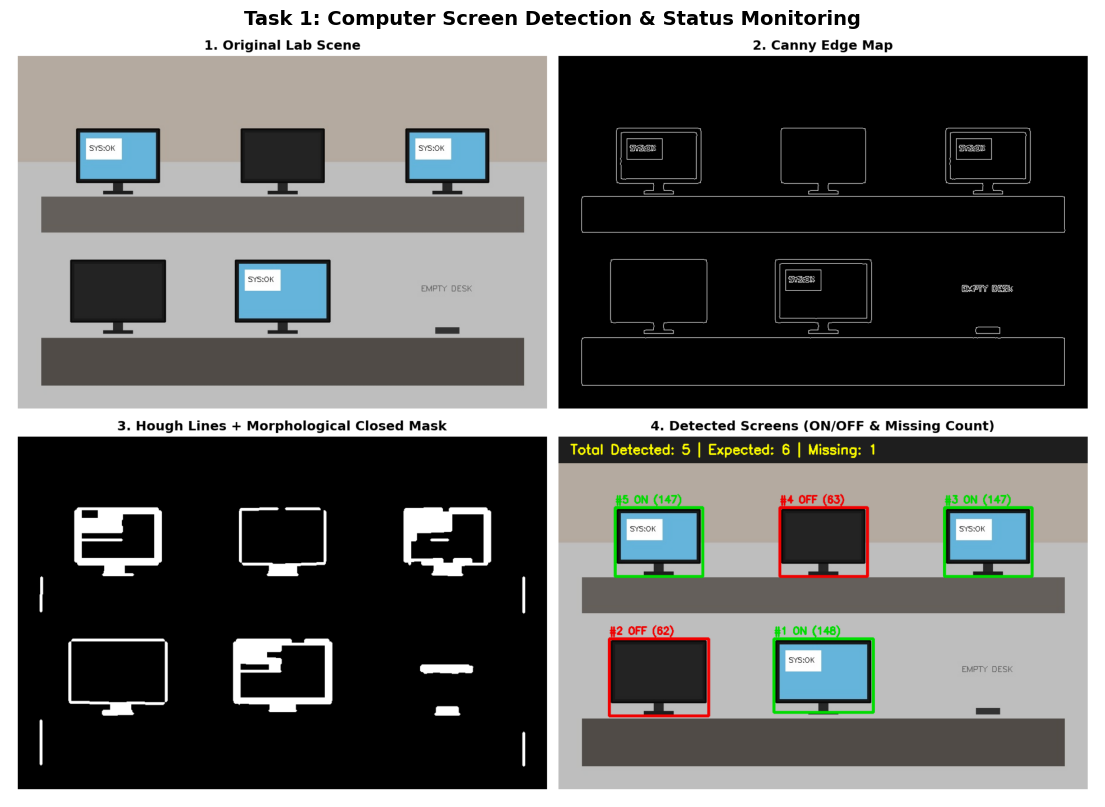

In [3]:
import task1_screen_detection
screens = task1_screen_detection.detect_screens("assets/lab_screens.jpg", "task1_screens_output.png", expected_count=6)

plt.figure(figsize=(14, 10))
plt.imshow(cv2.cvtColor(cv2.imread("task1_screens_output.png"), cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Task 1: Computer Screen Detection & Status Monitoring", fontsize=14, fontweight="bold")
plt.show()


---
## Task 2: Asset Tracking in a Computer Lab Using SIFT
**Technique:** SIFT (Scale-Invariant Feature Transform) + Brute-Force Matcher + Lowe's Ratio Test + RANSAC Homography.

### Parameters Chosen & Justification:
- `cv2.SIFT_create()`: Extracts 128-dimensional descriptors invariant to scale, rotation, and illumination.
- `Lowe's Ratio Test = 0.75`: Requires the best match distance to be $< 0.75 \times$ the runner-up distance, rejecting ambiguous descriptors.
- `RANSAC Reprojection Error = 5.0 pixels`: Tolerates minor perspective distortions while eliminating spatial outliers.
- `min_inliers = 15`: Ensures high-confidence certification of asset presence before logging in the inventory.



           LAB ASSET TRACKING INVENTORY REPORT
Asset Name      | Inliers  | Status       | Action
-------------------------------------------------------


Monitor         | 107      | PRESENT      | Logged in Station


Keyboard        | 9        | NOT FOUND    | Audit / Missing


CPU Tower       | 72       | PRESENT      | Logged in Station
Webcam          | 0        | NOT FOUND    | Audit / Missing



Task 2 output saved to task2_asset_tracking_output.png


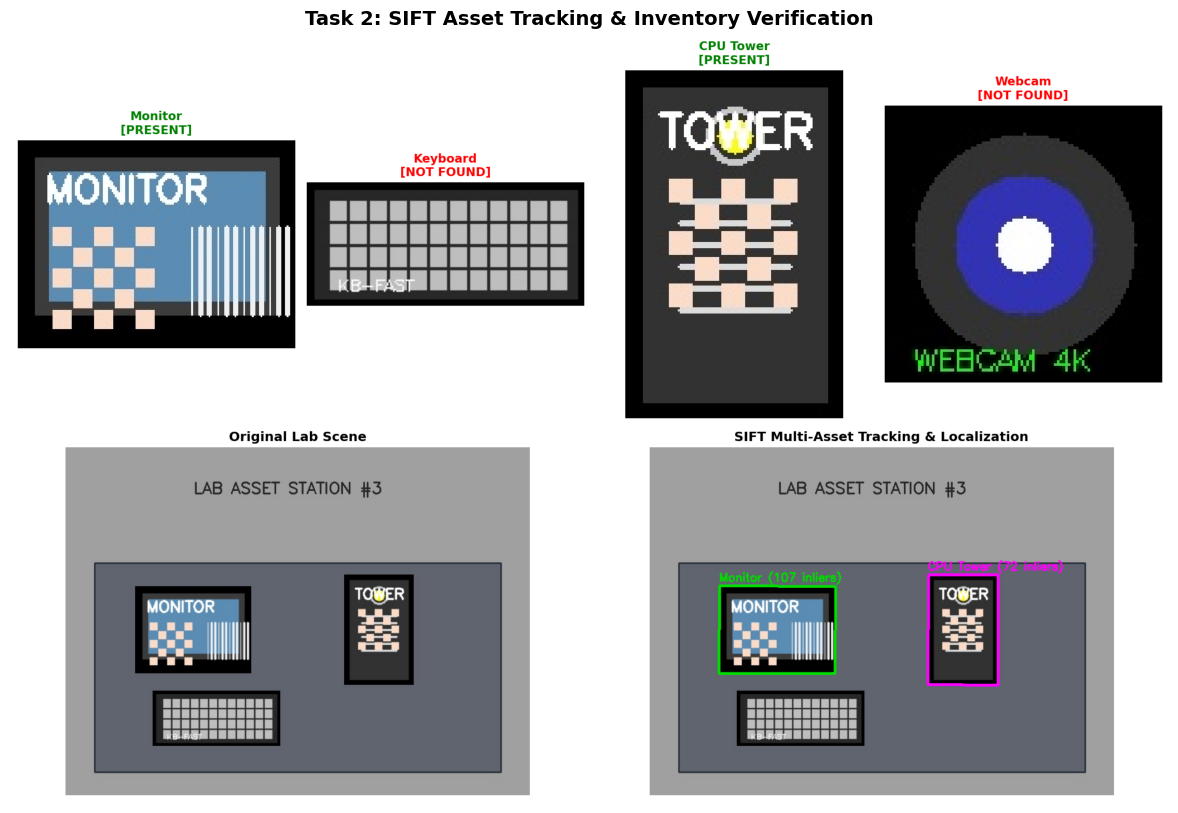

In [4]:
import task2_asset_tracking
inventory = task2_asset_tracking.track_assets("assets/lab_scene.jpg", "task2_asset_tracking_output.png", min_inliers=15)

plt.figure(figsize=(15, 10))
plt.imshow(cv2.cvtColor(cv2.imread("task2_asset_tracking_output.png"), cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Task 2: SIFT Asset Tracking & Inventory Verification", fontsize=14, fontweight="bold")
plt.show()


---
## Task 3: Anomaly Detection in Sensor Data Using Wavelet Transformation
**Technique:** Discrete Wavelet Transform (DWT), Noise Estimation via MAD, VisuShrink Universal Soft Thresholding, Inverse DWT, and Z-Score Outlier Flagging.

### Parameters Chosen & Justification:
- `Wavelet = 'db4'`: Daubechies 4 wavelet provides compact support and smooth wavelets, avoiding Haar blockiness.
- `Decomposition Level = 4`: Separates low-frequency operational dynamics from high-frequency shock faults.
- `Noise Estimation via MAD`: $\hat{\sigma} = \frac{\text{median}(|cD_1|)}{0.6745}$. Resistant to isolated impulse outliers.
- `Universal Threshold`: $\lambda = \hat{\sigma} \sqrt{2 \ln(N)}$. Asymptotically suppresses Gaussian noise floor.
- `Z-Score Cutoff > 3.0`: Standard 3-sigma empirical threshold (identifies samples outside $99.73\%$ normal residual variation).


Task 3 Complete:
 - Wavelet: db4 | Decomposition Level: 4
 - Estimated Noise Sigma (MAD): 0.3457
 - Universal Threshold: 1.2849
 - Known Injected Anomalies: [150, 420, 700, 850]
 - Detected Anomalies (z > 3.0): 6 points at [150, 420, 693, 700, 850, 949]
 - Output figure saved: task3_wavelet_anomaly.png


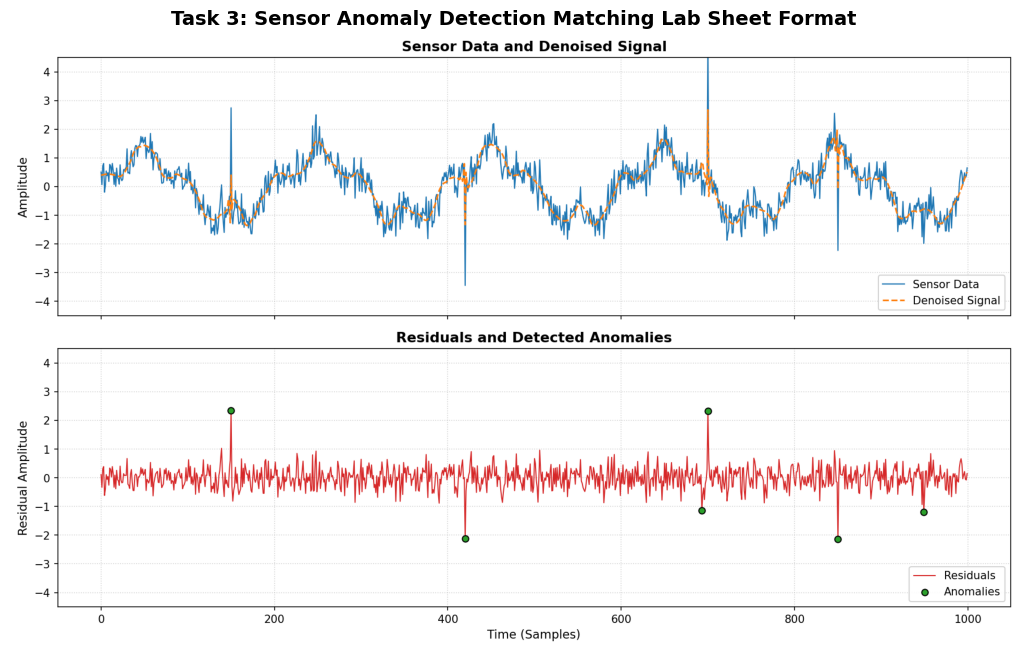

In [5]:
import task3_wavelet_anomaly
anom_res = task3_wavelet_anomaly.run_wavelet_anomaly_detection("assets/sensor_data.csv", "task3_wavelet_anomaly.png")

plt.figure(figsize=(13, 8))
plt.imshow(cv2.cvtColor(cv2.imread("task3_wavelet_anomaly.png"), cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Task 3: Sensor Anomaly Detection Matching Lab Sheet Format", fontsize=14, fontweight="bold")
plt.show()


---
## Task 4: Object Recognition (Using Video)
**Technique:** SIFT Feature Tracking across frames + RANSAC Homography + `cv2.perspectiveTransform` Bounding Box Localization.

### Parameters Chosen & Justification:
- `Lowe's Ratio Test = 0.75`: Discards false descriptor matches under scale and perspective transformations.
- `RANSAC Reprojection Threshold = 5.0`: Computes the projective homography matrix $H$ mapping reference coordinates to current video frame.
- `min_inliers = 15`: High confidence threshold prevents false-positive bounding boxes during object absence.


Task 4 Complete:
 - Processed frames: 50
 - Detected target in: 50/50 frames (100.0%)
 - Output video saved: task4_recognized_video.mp4
 - Output keyframe analysis saved: task4_recognition_output.png


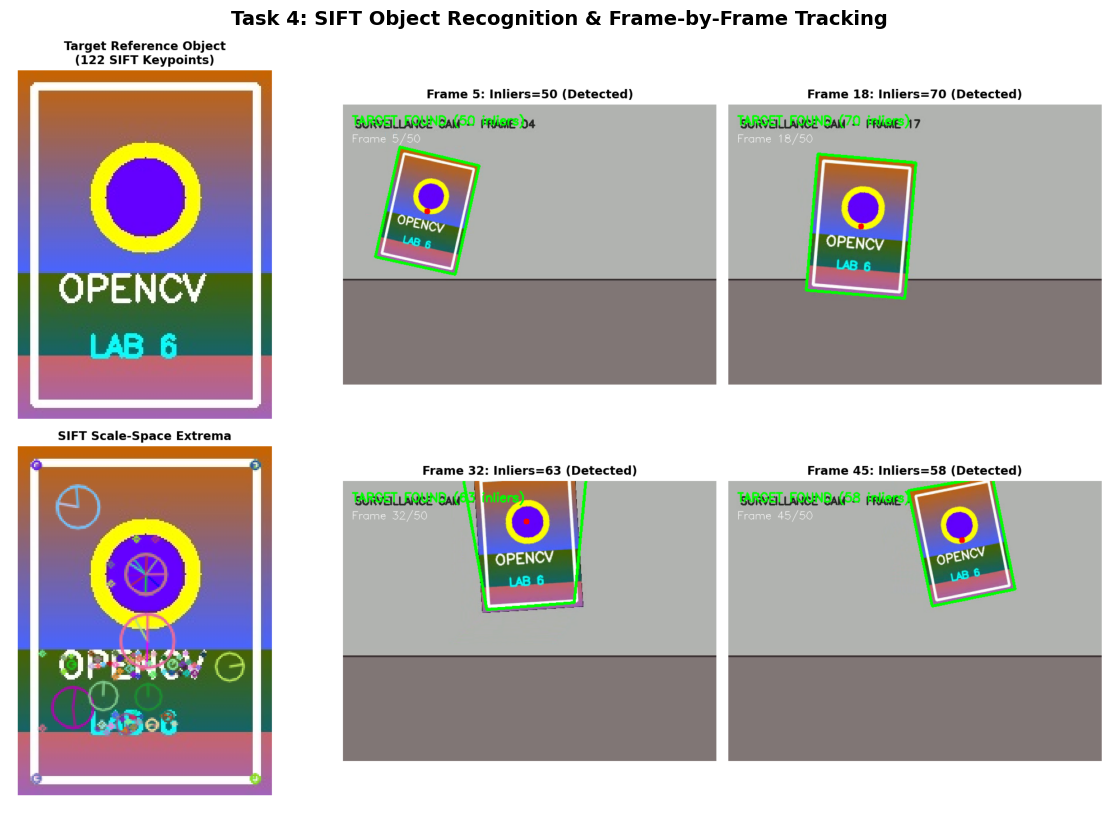

In [6]:
import task4_object_recognition
recog_res = task4_object_recognition.run_object_recognition("assets/object.jpg", "assets/test_video.mp4")

plt.figure(figsize=(15, 10))
plt.imshow(cv2.cvtColor(cv2.imread("task4_recognition_output.png"), cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Task 4: SIFT Object Recognition & Frame-by-Frame Tracking", fontsize=14, fontweight="bold")
plt.show()


---
## Task 5: Your Panoramic Image (SIFT Stitching)
**Technique:** SIFT Feature Detection & Matching + Pairwise RANSAC Homography + Perspective Warping + Seamless Compositing.

### Parameters Chosen & Justification:
- `cv2.BFMatcher(cv2.NORM_L2)`: Matches 128-d Euclidean descriptor vectors between overlapping panning photos.
- `Ratio 0.75`: Effectively identifies true correspondence pairs across overlapping fields of view.
- `Homography Mapping`: Transforms right image coordinates onto the left reference image plane.
- `Non-destructive Blending`: Merges overlapping regions without black border occlusion.


Stitching 3 panning captures into a single panoramic image...


 - Stitched Image 1 and 2: 275 matches, 222 RANSAC inliers.


 - Stitched Image 2 and 3: 133 matches, 36 RANSAC inliers.


Task 5 Complete: Final panorama size: 1170x500 pixels.
Saved visualization: task5_panorama_output.png
Saved stitched image: task5_panorama_stitched.png


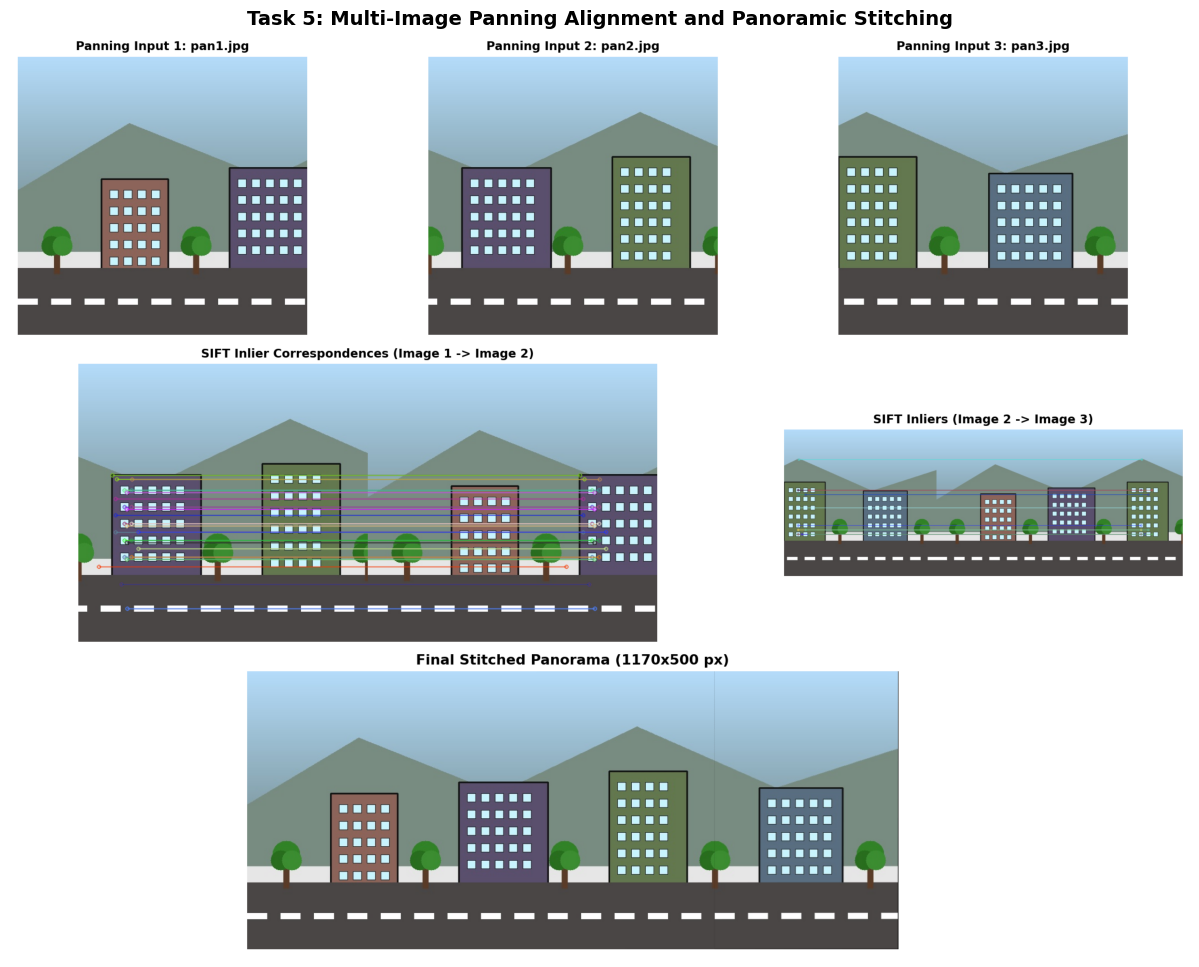

In [7]:
import task5_panorama
pano = task5_panorama.create_panorama(["assets/pan1.jpg", "assets/pan2.jpg", "assets/pan3.jpg"])

plt.figure(figsize=(16, 12))
plt.imshow(cv2.cvtColor(cv2.imread("task5_panorama_output.png"), cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Task 5: Multi-Image Panning Alignment and Panoramic Stitching", fontsize=14, fontweight="bold")
plt.show()


---
## Task 6: Autonomous Vehicle Lane Detection
**Technique:** Gaussian Blur + Canny Edge Detection + Trapezoidal ROI Mask + Probabilistic Hough Lines (`HoughLinesP`) + Slope Polarity Separation + Corridor Fill.

### Parameters Chosen & Justification:
- `Trapezoidal ROI`: Restricts detection to the vehicle's forward road surface, ignoring horizon, sky, and roadside foliage.
- `HoughLinesP(threshold=25, minLineLength=25, maxLineGap=80)`:
  - `maxLineGap=80`: Crucial for connecting dashed road markings into continuous trajectories.
  - `minLineLength=25`: Filters out gravel, asphalt texture, and minor pavement imperfections.
- `Slope Polarity Separation`:
  - In image coordinates ($y$ increases downwards), Left Lane has $m < 0$, Right Lane has $m > 0$.
- `Lane Extrapolation`: Fits median slopes and intercepts from hood level ($y=h$) to horizon ($y=0.58h$).


Task 6 Complete:
 - Hough segments detected: 13
 - Left lane segments: 7 | Right lane segments: 6
 - Saved multi-panel visualization: task6_lane_output.png
 - Saved annotated lane overlay: task6_lane_detected.png


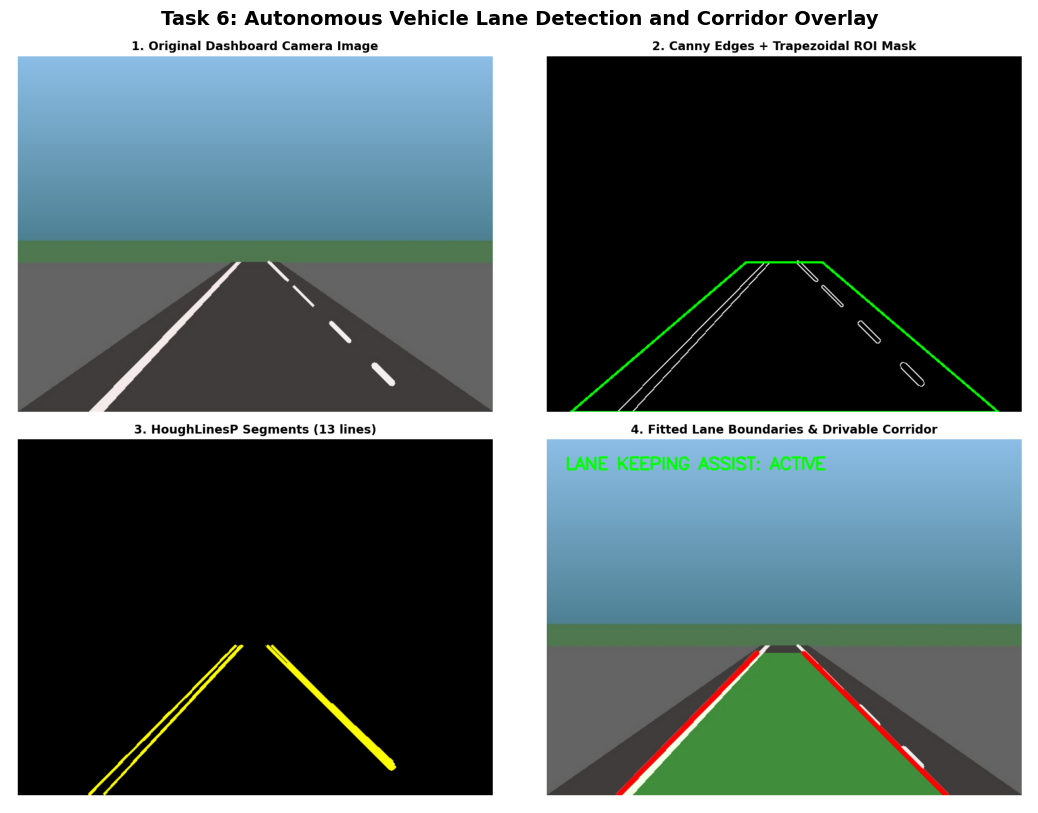

In [8]:
import task6_lane_detection
lane_res = task6_lane_detection.detect_lanes("assets/road.jpg", "task6_lane_output.png")

plt.figure(figsize=(14, 10))
plt.imshow(cv2.cvtColor(cv2.imread("task6_lane_output.png"), cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Task 6: Autonomous Vehicle Lane Detection and Corridor Overlay", fontsize=14, fontweight="bold")
plt.show()


---
## Task 7: Coins Detection and Automated Counting
**Technique:** Median Blur + Hough Gradient Circle Transformation (`cv2.HoughCircles`) + Centroid Marking + Sequential Coin Labeling.

### Parameters Chosen & Justification:
- `medianBlur(gray, 5)`: Suppresses specular coin glare and metal texture noise without blurring boundary circular edges.
- `HOUGH_GRADIENT with dp=1.2`: Gradient direction vectors vote for center coordinates in 2D space, eliminating 3D cone search cost.
- `minDist=28`: Enforces physical minimum spacing between coin centers, preventing duplicate concentric detections on the same coin.
- `param1=50`: Upper Canny threshold inside the circle detector.
- `param2=30`: Accumulator vote threshold for accepting a circle center.
- `minRadius=12, maxRadius=38`: Constrains search space strictly to physical coin sizes.


Task 7 Complete:
 - Total coins detected and counted: 23
   Coin #1: Center=(64, 39), Radius=24px
   Coin #2: Center=(47, 98), Radius=24px
   Coin #3: Center=(94, 75), Radius=24px
   Coin #4: Center=(135, 53), Radius=24px
   Coin #5: Center=(176, 83), Radius=24px
   ... and 18 additional coins verified.
 - Saved visualization plot: task7_coins_output.png
 - Saved annotated result image: task7_coins_detected.png


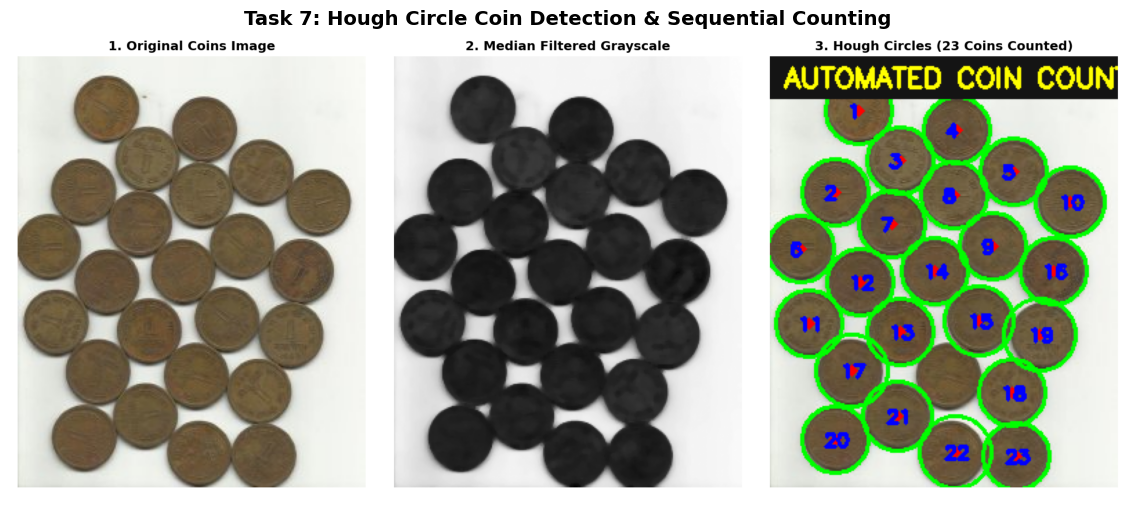

In [9]:
import task7_coins_counting
coin_res = task7_coins_counting.count_coins("coins.jpg", "task7_coins_output.png")

plt.figure(figsize=(15, 6))
plt.imshow(cv2.cvtColor(cv2.imread("task7_coins_output.png"), cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Task 7: Hough Circle Coin Detection & Sequential Counting", fontsize=14, fontweight="bold")
plt.show()


---
## Task 8: Smart Security System Using Boundary Detection
**Technique:** Polygonal Zone Masking + Canny Boundary Detection + Statistical Baseline Calibration + Temporal Streak Filtering.

### Parameters Chosen & Justification:
- `Predefined Security Polygon`: High-value restricted zone coordinates `[(200, 150), (500, 150), (500, 400), (200, 400)]`.
- `Baseline Calibration Window = 30 frames`: Measures ambient background noise ($\mu_{	ext{base}}, \sigma_{	ext{base}}$) in the empty zone.
- `Alarm Trigger Threshold`: $T = \mu_{	ext{base}} + 4\sigma_{	ext{base}} + 50$ edge pixels. Exceeds $99.99\%$ of ambient noise variations.
- `Streak Filter = 4 consecutive frames`: Prevents transient camera noise, single-frame lighting flicker, or small shadows from causing false alarms.


Calibrating baseline edge density over initial 30 frames...
 - Baseline Mean: 0.00 edge pixels
 - Baseline Std:  0.00
 - Alarm Trigger Threshold: 50.00 edge pixels


Task 8 Complete:
 - Total Video Frames: 60
 - Alarm Triggered Frames: 21
 - Saved security video: task8_security_alarm.mp4
 - Saved security summary plot: task8_security_output.png


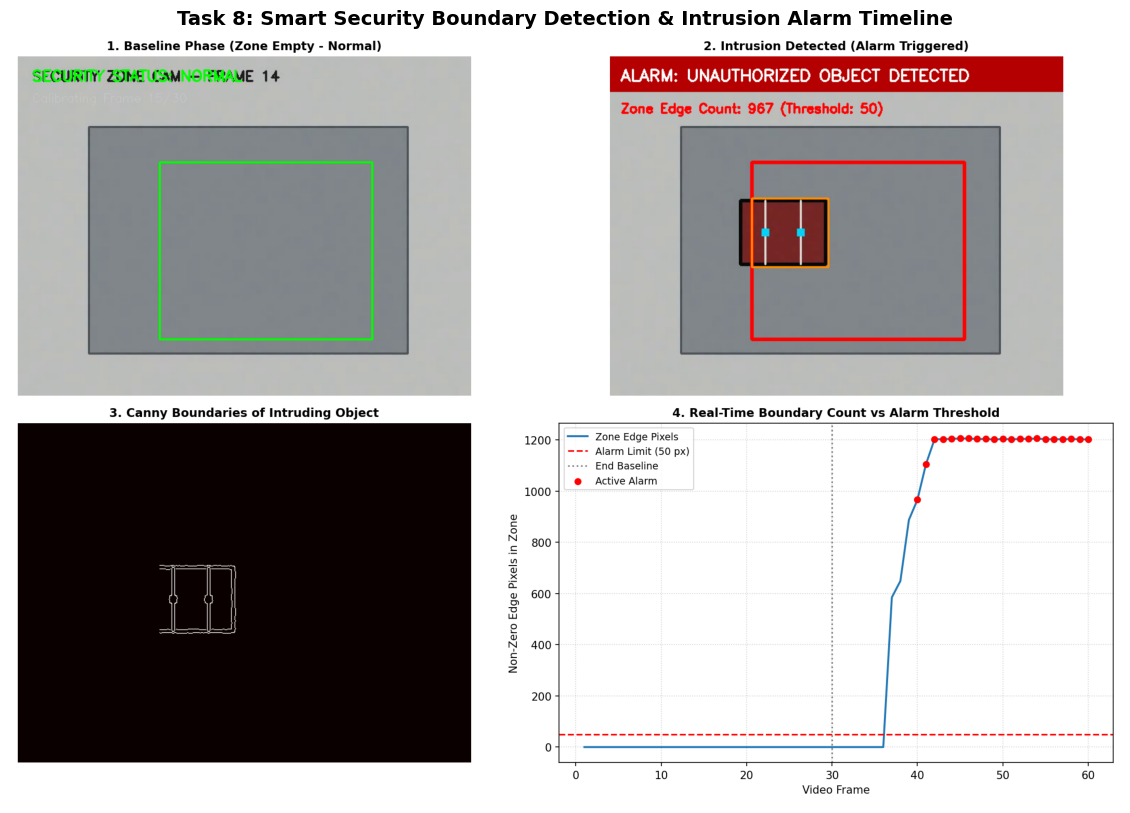

In [10]:
import task8_smart_security
sec_res = task8_smart_security.run_security_system("assets/security_video.mp4", "task8_security_alarm.mp4", "task8_security_output.png")

plt.figure(figsize=(15, 10))
plt.imshow(cv2.cvtColor(cv2.imread("task8_security_output.png"), cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Task 8: Smart Security Boundary Detection & Intrusion Alarm Timeline", fontsize=14, fontweight="bold")
plt.show()


---
## Summary of Lab 06 Results & Method Comparison

| Method | Task | Question Answered | Key Parameter(s) | Main Failure Mode & Mitigation |
| :--- | :--- | :--- | :--- | :--- |
| **Sobel** | Foundation | Gradient magnitude & direction | `ksize=3`, `cv2.CV_64F` | Noise sensitivity; mitigate with pre-blurring. |
| **Canny** | Foundation / 1, 6, 8 | Thin connected edges | Blur $\sigma$, thresholds $(50, 150)$ | Over-segmentation / noise; mitigate with hysteresis. |
| **LoG** | Foundation | Inflection point / zero-crossing | Blur $\sigma$, `cv2.Laplacian` | Extreme noise sensitivity; require Gaussian pre-smoothing. |
| **HoughLinesP** | Task 1 & 6 | Finite straight line segments | `threshold`, `minLineLength`, `maxLineGap` | Disconnected dashes; bridge with `maxLineGap`. |
| **HoughCircles** | Task 7 | Circular object centers & radii | `minDist`, `param2`, radius range | Duplicate detections; enforce `minDist` between coins. |
| **SIFT** | Task 2, 4, 5 | Scale & rotation invariant keypoints | Ratio $=0.75$, RANSAC reproj $=5.0$ | Textureless / repetitive surfaces; filter with Lowe's ratio. |
| **Wavelets** | Task 3 | Transient time-frequency anomalies | Wavelet family, level, MAD threshold | Coarse wavelet selection; use `db4` with VisuShrink. |

---
**End of Lab 06 Notebook**
